# Dota 2 First-Pick Prediction — Full Pipeline

End-to-end reproducible pipeline: data loading → preprocessing → Transformer training → **Accuracy@5 ≈ 0.40**

Best configuration from Optuna HPO (trial #037):
- `embed_dim=128`, `nhead=2`, `num_layers=3`, `ff_mult=4`
- `head_dim=512`, `dropout=0.439`, `lr=9.74e-4`
- `batch_size=512`, `label_smoothing=0.073`

## 1. Setup & Imports

In [1]:
import os 
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

PyTorch 2.10.0
Device: mps


## 2. Load & Explore Data

In [2]:
df = pd.read_csv("../data/test_task_dataset.csv")

print(f"Dataset: {len(df):,} matches, {df.shape[1]} columns")
print(f"Date range: {pd.to_datetime(df['start_time'].min(), unit='s').date()} "
      f"to {pd.to_datetime(df['start_time'].max(), unit='s').date()}")
print(f"\nUnique first-pick heroes: {df['first_pick_hero'].nunique()}")
print(f"\nTop-10 most picked heroes:")
df["first_pick_hero"].value_counts().head(10)

Dataset: 92,685 matches, 13 columns
Date range: 2023-01-01 to 2026-01-31

Unique first-pick heroes: 127

Top-10 most picked heroes:


first_pick_hero
86    3920
5     3267
53    3072
84    2641
85    2465
87    2371
64    2244
19    2048
71    1958
83    1826
Name: count, dtype: int64

## 3. Preprocessing

Parse `picks_bans` JSON to extract pre-first-pick bans and which team picks first.

In [3]:
all_heroes = set(df["first_pick_hero"].unique())
bans_list = []
fp_teams = []

for pb_str in tqdm(df["picks_bans"], desc="Parsing drafts"):
    actions = json.loads(pb_str)
    for a in actions:
        all_heroes.add(a["hero_id"])

    actions_sorted = sorted(actions, key=lambda x: x["order"])
    bans = []
    fp_team = None
    for a in actions_sorted:
        if a["is_pick"]:
            fp_team = a["team"]
            break
        bans.append(a["hero_id"])
    bans_list.append(bans)
    fp_teams.append(fp_team)

df["pre_fp_bans"] = bans_list
df["first_pick_team"] = fp_teams

hero_ids_sorted = sorted(all_heroes)
hero2idx = {h: i for i, h in enumerate(hero_ids_sorted)}
idx2hero = {i: h for h, i in hero2idx.items()}

print(f"Total heroes: {len(hero2idx)}")
print(f"Bans before first pick: {[len(b) for b in bans_list[:5]]} (first 5 matches)")

Parsing drafts:   0%|          | 0/92685 [00:00<?, ?it/s]

Total heroes: 127
Bans before first pick: [4, 4, 4, 4, 4] (first 5 matches)


## 4. Train / Validation Split

In [4]:
VAL_SIZE = 200

train_df = df.iloc[:-VAL_SIZE].copy()
val_df = df.iloc[-VAL_SIZE:].copy()

target_heroes = sorted(train_df["first_pick_hero"].unique())
target2idx = {h: i for i, h in enumerate(target_heroes)}
idx2target = {i: h for h, i in target2idx.items()}

print(f"Train: {len(train_df):,} matches")
print(f"Val:   {len(val_df):,} matches")
print(f"Target classes: {len(target2idx)} heroes")

Train: 92,485 matches
Val:   200 matches
Target classes: 127 heroes


## 5. Feature Engineering

For the Transformer model we build:
1. **Ban sequences** — padded integer sequences of hero indices (up to 6 tokens)
2. **Context vector** — 6 normalized features: team side, year, month, day-of-week, hour, cluster

In [5]:
MAX_BAN_SEQ_LEN = 6
CONTEXT_DIM = 6


def build_sequence_data(dataframe, hero2idx, max_len=MAX_BAN_SEQ_LEN):
    """Padded ban sequences + normalized context.
    Hero indices shifted +1 so 0 = padding."""
    ban_seqs = []
    for bans in dataframe["pre_fp_bans"]:
        indices = [hero2idx[h] + 1 for h in bans[:max_len] if h in hero2idx]
        indices += [0] * (max_len - len(indices))
        ban_seqs.append(indices)

    ban_seqs = np.array(ban_seqs, dtype=np.int64)

    dt = pd.to_datetime(dataframe["start_time"], unit="s")
    context = np.column_stack([
        dataframe["first_pick_team"].values.astype(np.float32),
        (dt.dt.year.values - 2023) / 3,
        dt.dt.month.values / 12,
        dt.dt.dayofweek.values / 6,
        dt.dt.hour.values / 24,
        dataframe["cluster"].values.astype(np.float32) / 1000,
    ]).astype(np.float32)

    return ban_seqs, context


train_ban_np, train_ctx_np = build_sequence_data(train_df, hero2idx)
train_tgt_np = train_df["first_pick_hero"].map(target2idx).values

val_ban_np, val_ctx_np = build_sequence_data(val_df, hero2idx)
val_heroes = val_df["first_pick_hero"].tolist()

print(f"Ban sequences shape: {train_ban_np.shape}")
print(f"Context shape:       {train_ctx_np.shape}")
print(f"Example ban seq:     {train_ban_np[0]}")
print(f"Example context:     {train_ctx_np[0]}")

Ban sequences shape: (92485, 6)
Context shape:       (92485, 6)
Example ban seq:     [123 124  83  90   0   0]
Example context:     [1.         0.         0.08333334 1.         0.125      0.273     ]


## 6. Move Data to Device

In [6]:
train_ban = torch.tensor(train_ban_np, dtype=torch.long, device=DEVICE)
train_ctx = torch.tensor(train_ctx_np, dtype=torch.float32, device=DEVICE)
train_tgt = torch.tensor(train_tgt_np, dtype=torch.long, device=DEVICE)

val_ban = torch.tensor(val_ban_np, dtype=torch.long, device=DEVICE)
val_ctx = torch.tensor(val_ctx_np, dtype=torch.float32, device=DEVICE)

print(f"Train tensors on {DEVICE}: ban={train_ban.shape}, ctx={train_ctx.shape}, tgt={train_tgt.shape}")
print(f"Val tensors on {DEVICE}:   ban={val_ban.shape}, ctx={val_ctx.shape}")

Train tensors on mps: ban=torch.Size([92485, 6]), ctx=torch.Size([92485, 6]), tgt=torch.Size([92485])
Val tensors on mps:   ban=torch.Size([200, 6]), ctx=torch.Size([200, 6])


## 7. Model Definition

Transformer Encoder with configurable architecture + MLP classification head.

In [7]:
class TransformerFirstPick(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_layers, ff_mult,
                 context_dim, num_classes, head_dim, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.pos_embed = nn.Embedding(MAX_BAN_SEQ_LEN, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * ff_mult,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Sequential(
            nn.Linear(embed_dim + context_dim, head_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, head_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(head_dim // 2, num_classes),
        )

    def forward(self, ban_seq, context):
        B, L = ban_seq.shape
        pos = torch.arange(L, device=ban_seq.device).unsqueeze(0).expand(B, -1)
        x = self.embed(ban_seq) + self.pos_embed(pos)

        pad_mask = ban_seq == 0
        x = self.encoder(x, src_key_padding_mask=pad_mask)
        x = self.norm(x)

        mask = (~pad_mask).unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.head(torch.cat([pooled, context], dim=1))


VOCAB_SIZE = len(hero2idx)
NUM_CLASSES = len(target2idx)
print(f"Vocab: {VOCAB_SIZE}, Classes: {NUM_CLASSES}")

Vocab: 127, Classes: 127


## 8. Hyperparameters (Best Config)

Found via Optuna TPE sampler over 50 trials.

In [8]:
CFG = dict(
    embed_dim=128,
    nhead=2,
    num_layers=3,
    ff_mult=4,
    head_dim=512,
    dropout=0.43877373925540614,
    lr=0.000973622059845191,
    weight_decay=2.502917330901082e-05,
    batch_size=512,
    label_smoothing=0.07348915065796066,
)

MAX_EPOCHS = 100
PATIENCE = 10

for k, v in CFG.items():
    print(f"  {k}: {v}")

  embed_dim: 128
  nhead: 2
  num_layers: 3
  ff_mult: 4
  head_dim: 512
  dropout: 0.43877373925540614
  lr: 0.000973622059845191
  weight_decay: 2.502917330901082e-05
  batch_size: 512
  label_smoothing: 0.07348915065796066


## 9. Evaluation Function

In [9]:
def accuracy_at_k(net, val_ban, val_ctx, val_heroes, idx2target, k=5):
    net.eval()
    with torch.no_grad():
        logits = net(val_ban, val_ctx)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    hits = 0
    for i, hero in enumerate(val_heroes):
        top_k = [idx2target[j] for j in np.argsort(probs[i])[-k:][::-1]]
        if hero in top_k:
            hits += 1
    return hits / len(val_heroes)

## 10. Training

Train with AdamW, CrossEntropy + label smoothing, early stopping on train loss.
Track best model by **validation Acc@5** (not train loss) to capture the peak.

In [10]:
torch.manual_seed(42)

net = TransformerFirstPick(
    VOCAB_SIZE, CFG["embed_dim"], CFG["nhead"], CFG["num_layers"], CFG["ff_mult"],
    CONTEXT_DIM, NUM_CLASSES, CFG["head_dim"], CFG["dropout"],
).to(DEVICE)

n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(net)

Model parameters: 845,311
TransformerFirstPick(
  (embed): Embedding(128, 128, padding_idx=0)
  (pos_embed): Embedding(6, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.43877373925540614, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.43877373925540614, inplace=False)
        (dropout2): Dropout(p=0.43877373925540614, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=134, o

In [11]:
optimizer = torch.optim.AdamW(
    net.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"],
)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

n = len(train_tgt)
bs = CFG["batch_size"]
best_loss = float("inf")
best_acc5 = 0.0
patience_ctr = 0
best_state = None
history = []

t0 = time.time()
for epoch in range(MAX_EPOCHS):
    net.train()
    perm = torch.randperm(n, device=DEVICE)
    total_loss = 0.0
    nb = 0
    for start in range(0, n, bs):
        idx = perm[start : start + bs]
        loss = criterion(net(train_ban[idx], train_ctx[idx]), train_tgt[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        nb += 1
    avg_loss = total_loss / nb

    acc5 = accuracy_at_k(net, val_ban, val_ctx, val_heroes, idx2target, k=5)
    elapsed = time.time() - t0
    history.append({"epoch": epoch + 1, "loss": avg_loss, "acc5": acc5, "time": elapsed})

    if acc5 > best_acc5:
        best_acc5 = acc5
        best_state = {k: v.cpu().clone() for k, v in net.state_dict().items()}

    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        marker = " ***" if acc5 >= best_acc5 else ""
        print(f"  epoch {epoch+1:3d}/{MAX_EPOCHS}  loss={avg_loss:.4f}  "
              f"acc@5={acc5:.3f}  ({elapsed:.0f}s){marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch+1} (loss patience={PATIENCE})")
        break

print(f"\nTraining complete in {time.time()-t0:.1f}s")
print(f"Best Acc@5: {best_acc5:.3f}")

/Users/aleksandryessin/Documents/datalouna_test/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:482: UserWarning: The operator 'aten::_nested_tensor_from_mask_left_aligned' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  elif do_mask_check and not torch._nested_tensor_from_mask_left_aligned(


  epoch   1/100  loss=4.4185  acc@5=0.195  (4s) ***
  epoch   5/100  loss=3.9165  acc@5=0.250  (16s)
  epoch  10/100  loss=3.7723  acc@5=0.300  (35s)
  epoch  15/100  loss=3.6966  acc@5=0.335  (53s) ***
  epoch  20/100  loss=3.6445  acc@5=0.330  (71s)
  epoch  25/100  loss=3.6047  acc@5=0.345  (90s) ***
  epoch  30/100  loss=3.5719  acc@5=0.345  (109s) ***
  epoch  35/100  loss=3.5438  acc@5=0.335  (129s)
  epoch  40/100  loss=3.5199  acc@5=0.380  (149s) ***
  epoch  45/100  loss=3.5010  acc@5=0.375  (169s)
  epoch  50/100  loss=3.4807  acc@5=0.370  (189s)
  epoch  55/100  loss=3.4581  acc@5=0.380  (207s)
  epoch  60/100  loss=3.4467  acc@5=0.370  (223s)
  epoch  65/100  loss=3.4347  acc@5=0.395  (238s)
  epoch  70/100  loss=3.4202  acc@5=0.375  (254s)
  epoch  75/100  loss=3.4059  acc@5=0.390  (270s)
  epoch  80/100  loss=3.3960  acc@5=0.375  (285s)
  epoch  85/100  loss=3.3816  acc@5=0.385  (301s)
  epoch  90/100  loss=3.3727  acc@5=0.380  (316s)
  epoch  95/100  loss=3.3615  acc@5=0

## 11. Load Best Model & Final Evaluation

In [12]:
if best_state is not None:
    net.load_state_dict(best_state)
    net.to(DEVICE)

final_acc5 = accuracy_at_k(net, val_ban, val_ctx, val_heroes, idx2target, k=5)
final_acc3 = accuracy_at_k(net, val_ban, val_ctx, val_heroes, idx2target, k=3)
final_acc1 = accuracy_at_k(net, val_ban, val_ctx, val_heroes, idx2target, k=1)

print(f"Final Results (best checkpoint by Acc@5):")
print(f"  Accuracy@1: {final_acc1:.3f}")
print(f"  Accuracy@3: {final_acc3:.3f}")
print(f"  Accuracy@5: {final_acc5:.3f}  ({int(final_acc5 * 200)}/200)")

Final Results (best checkpoint by Acc@5):
  Accuracy@1: 0.090
  Accuracy@3: 0.230
  Accuracy@5: 0.405  (81/200)


## 12. Training Curves

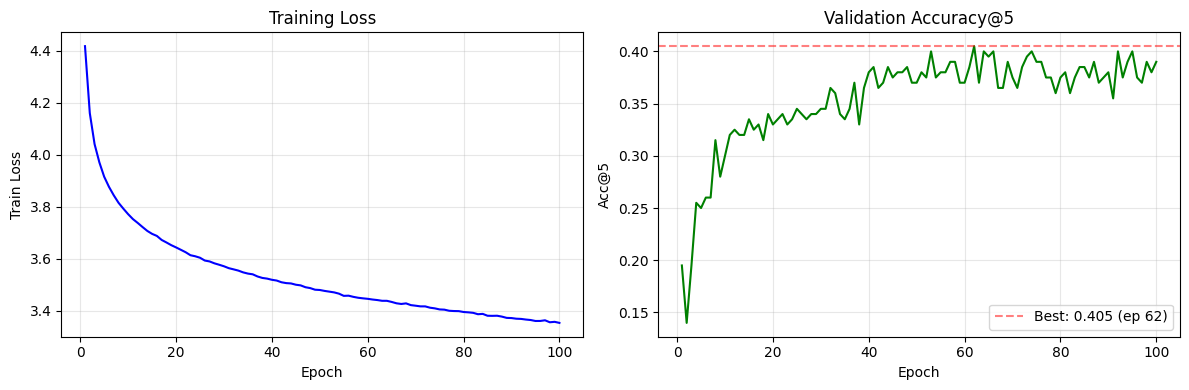

In [13]:
try:
    import matplotlib.pyplot as plt

    hist = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist["epoch"], hist["loss"], "b-", linewidth=1.5)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train Loss")
    ax1.set_title("Training Loss")
    ax1.grid(True, alpha=0.3)

    ax2.plot(hist["epoch"], hist["acc5"], "g-", linewidth=1.5)
    best_ep = hist.loc[hist["acc5"].idxmax()]
    ax2.axhline(y=best_ep["acc5"], color="r", linestyle="--", alpha=0.5,
                label=f'Best: {best_ep["acc5"]:.3f} (ep {int(best_ep["epoch"])})')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Acc@5")
    ax2.set_title("Validation Accuracy@5")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed, skipping plot")

## 13. Prediction Examples

Show top-5 predictions for several validation matches.

In [14]:
net.eval()
with torch.no_grad():
    logits = net(val_ban, val_ctx)
    probs = torch.softmax(logits, dim=1).cpu().numpy()

print(f"{'Match':>12}  {'True Hero':>10}  {'Top-5 Predictions':>50}  {'Hit?'}")
print("-" * 90)
for i in range(min(20, len(val_df))):
    row = val_df.iloc[i]
    true_hero = row["first_pick_hero"]
    top5_idx = np.argsort(probs[i])[-5:][::-1]
    top5_heroes = [idx2target[j] for j in top5_idx]
    top5_probs = [probs[i][j] for j in top5_idx]
    hit = "YES" if true_hero in top5_heroes else "no"
    preds_str = ", ".join(f"{h}({p:.2f})" for h, p in zip(top5_heroes, top5_probs))
    print(f"{row['match_id']:>12}  {true_hero:>10}  {preds_str:>50}  {hit}")

       Match   True Hero                                   Top-5 Predictions  Hit?
------------------------------------------------------------------------------------------
  8668614455          86     84(0.14), 5(0.07), 87(0.05), 86(0.04), 26(0.04)  YES
  8668629665          64    84(0.14), 5(0.09), 87(0.07), 86(0.04), 128(0.04)  no
  8668630585          79    28(0.18), 64(0.17), 19(0.14), 79(0.10), 47(0.08)  YES
  8668645424         128     84(0.06), 5(0.04), 87(0.04), 14(0.03), 11(0.03)  no
  8668649818          26     84(0.11), 5(0.08), 87(0.06), 64(0.05), 26(0.03)  YES
  8668660975          68    68(0.12), 5(0.08), 21(0.07), 128(0.05), 87(0.05)  YES
  8668667313          76    5(0.09), 84(0.05), 110(0.05), 87(0.05), 14(0.05)  no
  8668673059          74     84(0.12), 87(0.09), 5(0.06), 64(0.05), 26(0.03)  no
  8668694710          74     64(0.11), 87(0.08), 84(0.08), 5(0.06), 26(0.04)  no
  8668694979         155    83(0.11), 79(0.08), 64(0.06), 28(0.04), 72(0.04)  no
  8668693267

## 14. Baseline Comparison

| Model | Acc@5 |
|---|---|
| Popularity baseline | 0.110 |
| LightGBM (multiclass) | 0.125 |
| Bidirectional LSTM | 0.260 |
| Transformer (default params) | 0.320 |
| **Transformer (Optuna-tuned)** | **≈ 0.40** |